# 03 · Feature engineering สำหรับโมเดลทำนายระดับน้ำ X.44

**โจทย์:** ทุกสิ้นวัน t ใช้ข้อมูลที่รู้แล้วถึงวัน t ทำนาย **ระดับน้ำสูงสุดรายวันของ X.44 (หาดใหญ่ใน)** ในวัน t+1 … t+5
แล้วแปลงเป็นระดับเตือนภัย (ล้นตลิ่ง ≥ 7.15 ม., ท่วมพื้นที่ลุ่มต่ำ ≥ 7.40 ม.)

```
 ข้อมูลถึงวัน t ──► [โมเดล] ──► ระดับน้ำสูงสุด t+1, t+2, t+3, t+4, t+5
```

ขั้นตอนใน notebook นี้
1. ทำความสะอาดระดับน้ำรายชั่วโมง (sentinel, spike, ช่องว่างสั้น)
2. รวมเป็นตารางรายวัน + สร้าง feature (ระดับน้ำ, ฝน, ความชื้นในดิน, GloFAS, ฤดูกาล, ENSO)
3. สร้าง target ทั้ง 5 horizon และแบ่ง train / validation / test ตามเวลา
4. ตรวจการกระจายของ target และความสัมพันธ์ feature–target
5. baseline แบบ persistence (พรุ่งนี้ = วันนี้) เป็นเกณฑ์ขั้นต่ำที่โมเดลต้องชนะ
6. บันทึก `data/processed/features_daily.parquet`

โค้ดหลักอยู่ใน `mojito/features.py` เพื่อให้ขั้น real-time ใช้ชุดเดียวกัน

In [1]:
import matplotlib.pyplot as plt
import numpy
import pandas
from IPython.display import display

from mojito import config, features

RAW = config.RAW_DIR
PROCESSED = config.DATA_DIR / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": ["Noto Sans Thai", "DejaVu Sans"],
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
SPLIT_COLORS = {"train": "#4c72b0", "validation": "#dd8452", "test": "#c44e52"}

waterlevel_raw = pandas.read_parquet(RAW / "waterlevel_tele.parquet")
era5 = pandas.read_parquet(RAW / "era5_hourly.parquet")
rain_gauge = pandas.read_parquet(RAW / "rain_daily_gauge.parquet")
glofas = pandas.read_parquet(RAW / "glofas_daily.parquet")
oni = pandas.read_parquet(RAW / "oni.parquet")

## 1 · ทำความสะอาดระดับน้ำรายชั่วโมง
- **sentinel**: ค่า ≥ 999 (999999 = ไม่มีข้อมูล) → ว่าง
- **spike**: ค่าที่ห่างจาก median 7 ชั่วโมงรอบตัวเกิน 1 ม. → ว่าง (น้ำในคลองเหล่านี้ขึ้นจริงไม่เกิน ~0.5 ม./ชม.)
  และค่าทะเลสาบ SLA005 ที่เกิน 4 ม. (ช่วงน้ำท่วมใหญ่ 2568 ทะเลสาบสูงสุดแค่ 2.6 ม.) ซึ่งเป็น spike ติดกันหลายชั่วโมงที่ median filter จับไม่ได้
- **ช่องว่างสั้น** ≤ 6 ชั่วโมง → เติมด้วย linear interpolation
- วันที่มีข้อมูลน้อยกว่า 12 ชั่วโมง ไม่ใช้คำนวณค่ารายวัน

In [2]:
table, hourly, cleaning_report = features.build_daily_table(waterlevel_raw, era5, rain_gauge, glofas, oni)
cleaning_report

,sentinel_removed,spikes_removed,hours_gap_filled,hours_valid
station_code,,,,
ONE037,2,0,1827,31841
ONE038,0,0,25,30274
SLA002,15562,189,3886,101177
SLA005,0,315,2929,83979
SLA007,0,1,1828,97473
X.173A,0,2,6171,56711
X.174,0,4,6196,56625
X.44,0,0,6171,56718
X.90,0,2,6204,56629


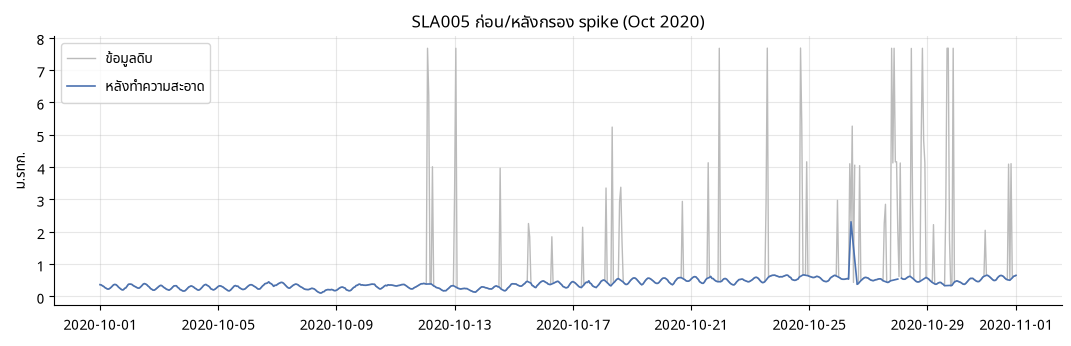

In [3]:
# ตัวอย่างก่อน/หลังทำความสะอาด: SLA005 (ปากรอ) มี spike มากที่สุด
raw_hourly = (
    waterlevel_raw[waterlevel_raw["station_code"] == "SLA005"]
    .set_index("timestamp")["waterlevel_msl"].resample("h").mean()
)
raw_hourly.index = raw_hourly.index.tz_localize(None)
spike_month = (raw_hourly - raw_hourly.rolling(7, center=True, min_periods=3).median()).abs().resample("MS").max().idxmax()
window = slice(spike_month, spike_month + pandas.DateOffset(months=1))

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(raw_hourly.loc[window], color="#bbbbbb", lw=1, label="ข้อมูลดิบ")
ax.plot(hourly["SLA005"].loc[window], color="#4c72b0", lw=1.2, label="หลังทำความสะอาด")
ax.set_ylabel("ม.รทก.")
ax.set_title(f"SLA005 ก่อน/หลังกรอง spike ({spike_month:%b %Y})")
ax.legend()
plt.show()

## 2 · ตาราง feature รายวัน
ทุก feature เป็นค่าที่ **รู้แล้ว ณ สิ้นวัน t** (ไม่มีข้อมูลอนาคตรั่วเข้ามา)

| กลุ่ม | feature | ความหมาย |
|---|---|---|
| ระดับน้ำ | `{สถานี}_max / _mean / _last` | สูงสุด / เฉลี่ย / ค่าสุดท้ายของวัน ที่ X.44, X.90, X.173A, X.174, SLA007, SLA005 |
| แนวโน้ม | `x44/x90/x173a_change_1d, _3d`, `x44_max_lag1..3` | ระดับน้ำเปลี่ยนไปเท่าไรใน 1/3 วัน และค่าย้อนหลัง |
| ฝน ERA5 | `era5_rain`, `era5_rain_3d/7d/14d/30d` | ฝนเฉลี่ยลุ่มน้ำ รายวันและสะสม |
| ฝนสถานี | `gauge_rain`, `gauge_rain_3d/7d`, `gauge_count` | ฝนเฉลี่ยจากสถานีในตัวเมือง และจำนวนสถานีที่มีข้อมูล |
| ความชื้นในดิน | `soil_0_7`, `soil_7_28`, `soil_28_100` | ERA5 เฉลี่ยลุ่มน้ำ (m³/m³) |
| GloFAS | `glofas_utapao_main`, `glofas_utapao_upstream`, `_change_1d` | ปริมาณน้ำท่าจำลอง |
| ฤดูกาล / ENSO | `month`, `doy_sin`, `doy_cos`, `oni` | ONI เลื่อน 2 เดือนตามเวลาที่ประกาศจริง |

**คอลัมน์ที่ไม่ใช่ feature**
- `target_h1..h5` ระดับน้ำสูงสุดวัน t+h
- `target_delta_h1..h5` = target − ระดับวันนี้
- `oracle_rain_next1..5d` ฝนที่ตกจริงในอนาคต — **ห้ามใช้เป็น feature ปกติ** ใช้เฉพาะทดลองกรณี "พยากรณ์ฝนแม่น 100%" เพื่อหาเพดานความแม่นยำ

In [4]:
feature_columns = features.feature_columns(table)
print(f"ตาราง: {len(table):,} วัน ({table.index.min():%Y-%m-%d} ถึง {table.index.max():%Y-%m-%d}), {len(feature_columns)} features")

missing = (table[feature_columns].isna().mean() * 100).sort_values(ascending=False)
display(missing[missing > 0].round(1).to_frame("% ค่าว่าง").T)

ตาราง: 2,426 วัน (2020-02-13 ถึง 2026-10-04), 46 features


,sla005_mean,sla005_max,sla005_last,gauge_count,gauge_rain,gauge_rain_7d,gauge_rain_3d,x90_change_3d,x44_change_3d,x90_change_1d,...,sla007_max,sla007_last,soil_7_28,era5_rain,soil_0_7,era5_rain_14d,era5_rain_7d,era5_rain_3d,soil_28_100,era5_rain_30d
% ค่าว่าง,30.4,30.4,30.4,3.7,3.7,3.7,3.7,3.0,2.6,2.6,...,1.9,1.9,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3


SLA005 (ทะเลสาบ) ว่าง ~30% จากช่วงที่สถานีขาดหายปี 2024–2025 — LightGBM รับค่าว่างได้ แต่ถ้าใช้ LSTM ต้องเติมค่าหรือตัด feature นี้

## 3 · Target และการแบ่งข้อมูลตามเวลา
- **train**: 2020-02 – 2023 · **validation**: 2024 · **test**: 2025 – ปัจจุบัน (มีเหตุการณ์ พ.ย. 2568)
- แบ่งตามเวลา ไม่สุ่ม เพราะข้อมูลวันติดกันคล้ายกันมาก การสุ่มจะทำให้ผลดูดีเกินจริง

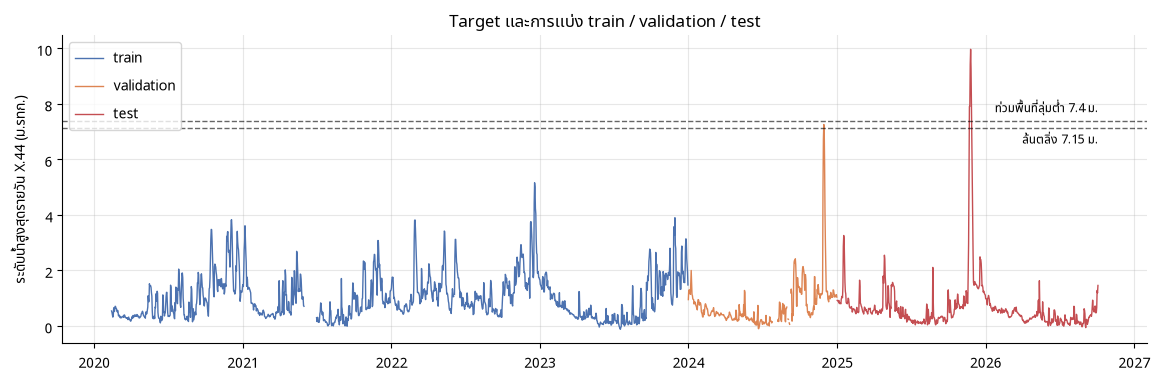

,วัน,ระดับสูงสุด,percentile_99,ขึ้นสูงสุดใน5วัน,วันล้นตลิ่ง,วันท่วมพื้นที่ลุ่ม
split,,,,,,
train,1418,5.16,3.58,3.24,0,0
validation,366,7.26,5.38,6.10,1,0
test,642,9.97,6.04,7.65,6,6


In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
for split, color in SPLIT_COLORS.items():
    part = table.loc[table["split"] == split, "x44_max"]
    ax.plot(part.index, part, color=color, lw=1, label=split)
for name, level in features.ALERT_LEVELS.items():
    ax.axhline(level, ls="--", lw=1, color="k", alpha=0.6)
    above = level == max(features.ALERT_LEVELS.values())
    ax.text(table.index.max(), level + (0.1 if above else -0.1), f"{name} {level} ม.",
            fontsize=9, ha="right", va="bottom" if above else "top")
ax.set_ylabel("ระดับน้ำสูงสุดรายวัน X.44 (ม.รทก.)")
ax.set_title("Target และการแบ่ง train / validation / test")
ax.legend(loc="upper left")
plt.show()

summary = table.groupby("split", sort=False).agg(
    วัน=("x44_max", "size"),
    ระดับสูงสุด=("x44_max", "max"),
    percentile_99=("x44_max", lambda s: s.quantile(0.99)),
    ขึ้นสูงสุดใน5วัน=("target_delta_h5", "max"),
    วันล้นตลิ่ง=("x44_max", lambda s: (s >= 7.15).sum()),
    วันท่วมพื้นที่ลุ่ม=("x44_max", lambda s: (s >= 7.40).sum()),
).reindex(["train", "validation", "test"])
summary.round(2)

### ⚠️ ปัญหาสำคัญ: น้ำท่วมใน test สูงกว่าทุกอย่างที่โมเดลเคยเห็นตอน train
- ชุด train ระดับน้ำสูงสุดแค่ **5.16 ม.** และไม่มีวันล้นตลิ่งเลย แต่ชุด test พีคที่ **9.97 ม.**
- โมเดลกลุ่ม decision tree (XGBoost / LightGBM) **ทำนายเกินค่าสูงสุดของ target ที่เห็นตอน train ไม่ได้**
  → ถ้าทำนายระดับน้ำตรงๆ จะทำนายเหตุการณ์ 2568 ได้ไม่เกิน ~5 ม.
- แม้แต่การขึ้นของน้ำใน 5 วันก็เกินช่วง train (7.65 vs 3.24 ม.)

**แนวทางที่จะทดสอบใน notebook 04**
1. ทำนาย **การเปลี่ยนแปลง** (`target_delta_h*`) แล้วบวกกลับกับระดับวันนี้ แทนการทำนายระดับตรงๆ
2. ใช้โมเดลที่ extrapolate ได้: linear / ridge, LightGBM `linear_tree=True`, LSTM
3. เลือก hyperparameter ด้วย validation 2024 (พีค 7.26 ม.) ซึ่งเป็นเหตุการณ์ใกล้ล้นตลิ่งครั้งเดียวก่อน test
4. (ทางเลือก) ขยายชุด train ด้วยเหตุการณ์ในอดีตผ่าน GloFAS/ERA5 ปี 1997–2019 ซึ่งมีน้ำท่วมปี 2543, 2548, 2553

## 4 · ความสัมพันธ์ feature กับ target (ชุด train)
Spearman correlation ระหว่างแต่ละ feature กับ **การเปลี่ยนแปลงของระดับน้ำ** วันถัดไป (h=1) และอีก 5 วัน (h=5)
— ดูว่า feature ไหนบอกได้ว่าน้ำ "กำลังจะขึ้น"

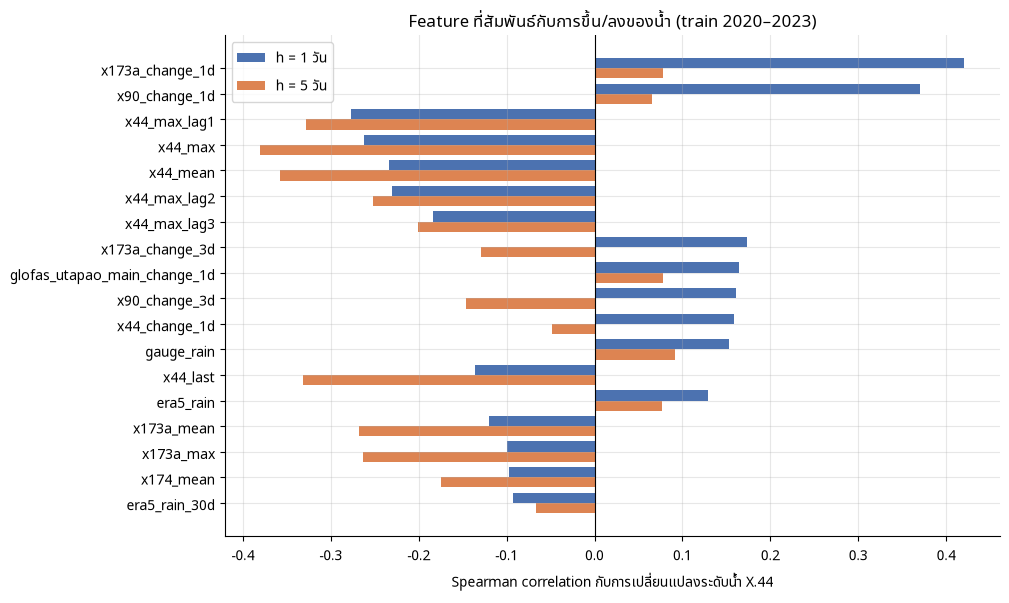

In [6]:
train = table[table["split"] == "train"]
correlation = pandas.DataFrame({
    f"h={h}": train[feature_columns].corrwith(train[f"target_delta_h{h}"], method="spearman")
    for h in (1, 5)
}).dropna()
top = correlation.reindex(correlation["h=1"].abs().sort_values(ascending=False).index).head(18)

fig, ax = plt.subplots(figsize=(10, 6.5))
positions = numpy.arange(len(top))
ax.barh(positions - 0.2, top["h=1"], height=0.4, label="h = 1 วัน", color="#4c72b0")
ax.barh(positions + 0.2, top["h=5"], height=0.4, label="h = 5 วัน", color="#dd8452")
ax.set_yticks(positions, top.index)
ax.invert_yaxis()
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Spearman correlation กับการเปลี่ยนแปลงระดับน้ำ X.44")
ax.set_title("Feature ที่สัมพันธ์กับการขึ้น/ลงของน้ำ (train 2020–2023)")
ax.legend()
plt.show()

## 5 · Baseline: persistence (ระดับน้ำ t+h = ระดับน้ำวันนี้)
เป็นเกณฑ์ขั้นต่ำ — โมเดลที่ไม่ชนะ persistence ถือว่าไม่มีประโยชน์
วัดทั้งทุกวัน และเฉพาะ **วันน้ำหลาก** (target ≥ 4 ม.) เพราะวันปกติน้ำแทบไม่เปลี่ยน ทำให้ MAE รวมดูดีเกินจริง

In [7]:
rows = []
for split in ["train", "validation", "test"]:
    part = table[table["split"] == split]
    for h in features.HORIZONS:
        valid = part[[f"target_h{h}", "x44_max"]].dropna()
        error = (valid[f"target_h{h}"] - valid["x44_max"]).abs()
        high = valid[f"target_h{h}"] >= 4
        rows.append({
            "split": split, "h": h,
            "MAE ทุกวัน (ม.)": error.mean(),
            "MAE วันน้ำหลาก (ม.)": error[high].mean() if high.any() else numpy.nan,
            "จำนวนวันน้ำหลาก": int(high.sum()),
        })
persistence = pandas.DataFrame(rows)
print("จำนวนวันน้ำหลาก (target ≥ 4 ม.):",
      persistence.groupby("split")["จำนวนวันน้ำหลาก"].first().reindex(["train", "validation", "test"]).to_dict())
for metric in ["MAE ทุกวัน (ม.)", "MAE วันน้ำหลาก (ม.)"]:
    display(persistence.pivot(index="h", columns="split", values=metric)[["train", "validation", "test"]]
            .round(2).rename_axis(columns=metric))

จำนวนวันน้ำหลาก (target ≥ 4 ม.): {'train': 5, 'validation': 6, 'test': 9}


MAE ทุกวัน (ม.),train,validation,test
h,,,
1,0.19,0.16,0.14
2,0.31,0.26,0.22
3,0.39,0.33,0.28
4,0.44,0.38,0.32
5,0.48,0.41,0.35


MAE วันน้ำหลาก (ม.),train,validation,test
h,,,
1,0.87,1.54,1.35
2,1.68,2.75,2.51
3,2.09,3.61,3.61
4,2.27,4.15,4.24
5,2.44,4.47,4.78


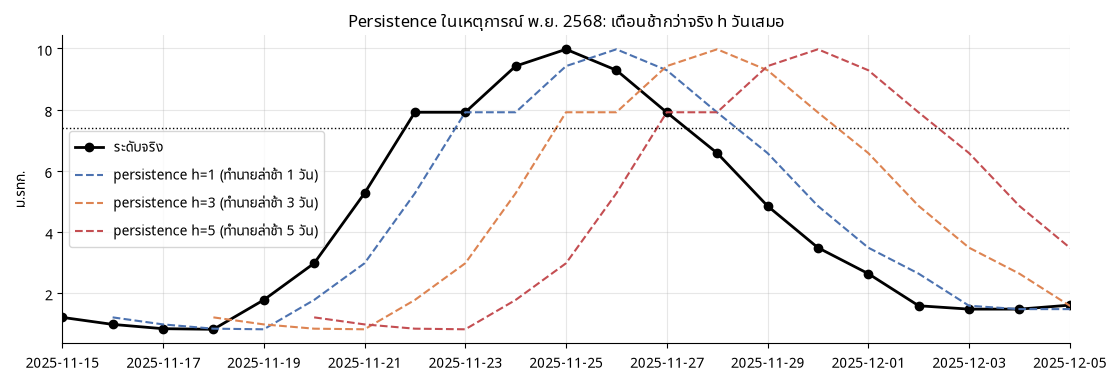

In [8]:
event = table.loc["2025-11-15":"2025-12-05"]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(event.index, event["x44_max"], color="k", lw=2, marker="o", label="ระดับจริง")
for h, color in [(1, "#4c72b0"), (3, "#dd8452"), (5, "#c44e52")]:
    ax.plot(event.index + pandas.Timedelta(days=h), event["x44_max"], ls="--", color=color,
            label=f"persistence h={h} (ทำนายล่าช้า {h} วัน)")
ax.axhline(7.40, color="k", ls=":", lw=1)
ax.set_xlim(event.index.min(), event.index.max())
ax.set_ylabel("ม.รทก.")
ax.set_title("Persistence ในเหตุการณ์ พ.ย. 2568: เตือนช้ากว่าจริง h วันเสมอ")
ax.legend()
plt.show()

## 6 · บันทึกผล

In [9]:
output = PROCESSED / "features_daily.parquet"
table.to_parquet(output)
print(f"saved {output.relative_to(config.ROOT)}: {table.shape[0]:,} แถว × {table.shape[1]} คอลัมน์")

saved data/processed/features_daily.parquet: 2,426 แถว × 62 คอลัมน์


## สรุป
- ได้ตารางรายวัน 2020-02 – 2026-10 พร้อม 46 features, target 5 horizon (ระดับ และการเปลี่ยนแปลง)
- ระดับน้ำต้นน้ำ (X.90, X.173A) และแนวโน้มของมัน รวมถึงฝนสะสม/ความชื้นในดิน เป็นกลุ่ม feature ที่สัมพันธ์กับการขึ้นของน้ำมากที่สุด
- ความท้าทายหลักของโปรเจค: **เหตุการณ์ test (9.97 ม.) อยู่นอกช่วงข้อมูล train (≤ 5.16 ม.)**
  → notebook 04 จะเทียบ persistence, ridge, LightGBM (ทำนายระดับ vs ทำนายการเปลี่ยนแปลง, linear_tree) และวัดผลเฉพาะวันน้ำหลากแยกจากวันปกติ